# Predicting the Sale Price of Bulldozers using Machine Learning 🚜

In this notebook, we're going to go through an example machine learning project with the goal of predicting the sale price of bulldozers.

## 1. Problem Defination

> How well can we predic the future sale prize of a bulldozer, given its characteristics and previous examples of how much similar bulldozers have been sold for ?

## 2. Data

The data is downloaded from the Kaggle Bluebook for Bulldozers competition: https://www.kaggle.com/c/bluebook-for-bulldozers/data

There are 3 main datasets:
1. **Train.csv** - Historical bulldozer sales examples up to 2011 (close to 400,000 examples with 50+ different attributes, including SalePrice which is the target variable).
2. **Valid.csv** - Historical bulldozer sales examples from January 1 2012 to April 30 2012 (close to 12,000 examples with the same attributes as Train.csv).
3. **Test.csv**  - Historical bulldozer sales examples from May 1 2012 to November 2012 (close to 12,000 examples but missing the SalePrice attribute, as this is what we'll be trying to predict).

## 3. Evaluation
The evaluation metric for this competition is the RMSLE (root mean squared log error) between the actual and predicted auction prices.

For more on the evaluation of this project check: https://www.kaggle.com/c/bluebook-for-bulldozers/overview/evaluation

**Note:** The goal for most regression evaluation metrics is to minimize the error. For example, our goal for this project will be to build a machine learning model which minimises RMSLE.

## 4. Features
Kaggle provides a data dictionary detailing all of the feature of this dataset.

We can download the full version of this file directly from the Kaggle competition page https://www.kaggle.com/competitions/bluebook-for-bulldozers

## 1. Importing the data and preparing it for modeling

Let's import all the libraries we need and the data for this project

In [68]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}") 

pandas version: 3.0.3
NumPy version: 2.5.0
matplotlib version: 3.11.0


Let's import the TrainAndValid.csv file and turn it into a pandas DataFrame.

In [69]:
# Import training and validation sets
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv",
                 low_memory=False)

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   saledate                  412698 non-null  str    
 10  fiModelDesc               412698 non-null  str    
 11  fiBaseModel               412698 non-null  str    
 12  fiSecondaryDesc           271971 non-null  str    
 13  fiModelSeries             58667 non-null   str    
 14 

Woah! Over 400,000 entries! 
Thats a much larger dataset we'll we working on.

In [71]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

In [72]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='str')

One thing we noticed is that the the `saledate` column is being treated as python string.

In [73]:
df.saledate[:1000]

0      11/16/2006 0:00
1       3/26/2004 0:00
2       2/26/2004 0:00
3       5/19/2011 0:00
4       7/23/2009 0:00
            ...       
995     7/16/2009 0:00
996     6/14/2007 0:00
997     9/22/2005 0:00
998     7/28/2005 0:00
999     6/16/2011 0:00
Name: saledate, Length: 1000, dtype: str

In [74]:
df.saledate.dtype

<StringDtype(storage='python', na_value=nan)>

Since we are working on a **time series** problem (a machine learning problem with a time component). Tt's probably worth it to turn these string into Python `datetime` objects.

Before we do, let's try visualize our `saledate` column against our `SalePrice` column.

To do so, we can create a scatter plot.

And to prevent our plot from being too big, how about we visualize the first 1000 values.

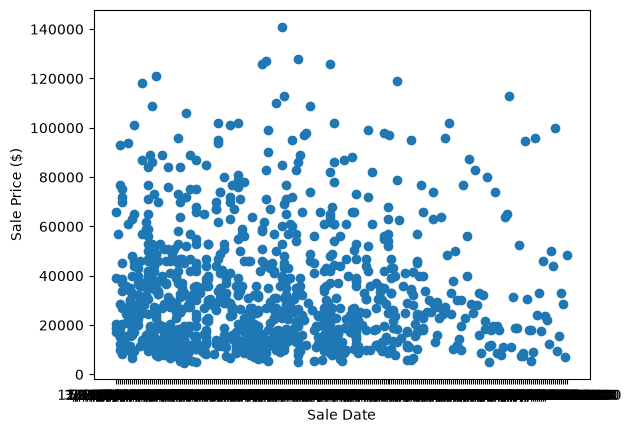

In [75]:
fig, ax = plt.subplots()
ax.scatter(x=df["saledate"][:1000], # visualize the first 1000 values
           y=df["SalePrice"][:1000])
ax.set_xlabel("Sale Date")
ax.set_ylabel("Sale Price ($)");

Hmm... looks like the x-axis is quite crowded.

Maybe we can fix this by turning the saledate column into datetime format.

Good news is that is looks like our SalePrice column is already in float64 format so we can view its distribution directly from the DataFrame using a histogram plot.

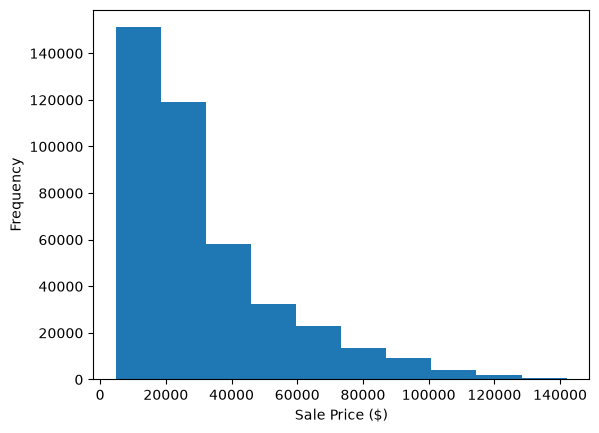

In [76]:
# View SalePrice Distribution
df.SalePrice.plot.hist(xlabel = "Sale Price ($)");

### 1.1 Parsing Dates

When working with time series data, it's a good idea to make sure any date data is the format of a datetime object (a Python data type which encodes specific information about dates).

In [ ]:

# Import data again but this time parse dates
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv",
                 low_memory=False,
                 parse_dates=["saledate"])

In [ ]:
df.saledate.dtype

Nice!

Looks like our saledate column is now of type datetime64

In [ ]:
df["saledate"][:10]

Let's visualize our saledate column against our SalePrice column again

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=df["saledate"][:1000], # visualize the first 1000 values
           y=df["SalePrice"][:1000])
ax.set_xlabel("Sale Date")
ax.set_ylabel("Sale Price ($)");

### 1.2 Sorting our DataFrame by saledate

In [ ]:
# Sort DataFrame in date order
df.sort_values(by=["saledate"], inplace=True, ascending=True)
df.saledate.head(10)

In [ ]:
df.saledate.tail(10)

### 1.3 Adding extra features to our DataFrame
One way to potentially increase the predictive power of our data is to enhance it with more features.

This practice is known as feature engineering, taking existing features and using them to create more/different features.

For now, we'll use our saledate column to add extra features such as:

1. Year of sale
2. Month of sale
3. Day of sale
4. Day of week sale (e.g. Monday = 1, Tuesday = 2)
5. Day of year sale (e.g. January 1st = 1, January 2nd = 2)

Since we're going to be manipulating the data, we'll make a copy of the original DataFrame and perform our changes there.

This will keep the original DataFrame in tact if we need it again.

In [ ]:
# Make a copy of the original DataFrame to perform edits on
df_tmp = df.copy()

In [ ]:
# Add datetime parameters for saledate
df_tmp["saleYear"] = df_tmp.saledate.dt.year
df_tmp["saleMonth"] = df_tmp.saledate.dt.month
df_tmp["saleDay"] = df_tmp.saledate.dt.day
df_tmp["saleDayofweek"] = df_tmp.saledate.dt.dayofweek
df_tmp["saleDayofyear"] = df_tmp.saledate.dt.dayofyear

In [ ]:
df_tmp.head().T

In [ ]:
# Now we've enriched our DataFrame with date time features, we can remove 'saledate'
df_tmp.drop("saledate", axis=1, inplace=True)

### 1.4 Inspect values of other columns

How about we see which states sell the most bulldozers?

In [ ]:
df_tmp.state.value_counts()

Woah! Looks like Flordia sells a fair few bulldozers.

### 2. Model driven data exploration
We've performed a small Exploratory Data Analysis (EDA) as well as enriched it with some `datetime` attributes, now let's try to model it.

Following the Scikit-Learn machine learning map and taking into account the fact we've got over 100,000 examples, we find that the RandomForestRegressor model might be a good candidate.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_jobs=-1,
                              random_state=42)

model.fit(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])                              

Oh no!

When we try to fit our model to the data, we get a value error.
The problem here is that some of the features of our data are in string format and machine learning models love numbers.

And typically, machine learning models require all data to be in numerical format as well as all missing values to be filled.

In [ ]:
# Check for missing values and different datatypes 
df_tmp.info();

In [ ]:
# Check for total missing values per column
df_tmp.isna().sum()

Woah! It looks like our DataFrame has quite a few missing values.

Not to worry, we can absolutely fix it.

How about we start by tring to turn all of our data in numbers?

### 2.1 Converting string to categories

One way we can turn all of our data into numbers is by converting them into pandas categories.

In [ ]:
df_tmp.head().T

In [ ]:
# Find the columns which contain strings
for lable, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        print(lable)

In [ ]:
# This will turn all of the string values into category values
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        df_tmp[label] = content.astype("category")

In [ ]:
df_tmp.info()

In [ ]:
print(df_tmp.dtypes)

In [ ]:
df_tmp.state.cat.categories

In [ ]:
df_tmp.state.cat.codes

This gives us a numeric representation of our object/string datatype columns.

### 2.2 Saving our preprocessed data

Before we start doing any further preprocessing steps on our DataFrame, how about we save our current DataFrame to file so we could import it again later if necessary.

In [ ]:
# Export current tmp dataframe
df_tmp.to_csv("data/bluebook-for-bulldozers/train_tmp.csv",
              index=False)

In [ ]:
# Import preprocessed data
df_tmp = pd.read_csv("data/bluebook-for-bulldozers/train_tmp.csv",
                     low_memory=False)
df_tmp.head().T

### 2.2 Finding missing values

In [ ]:
# Checking missing values
df_tmp.isna().sum().sort_values(ascending=False)

Ok, it seems like there are a fair few columns with missing values and there are several datatypes across these columns (numerical, categorical).

How about we break the problem down and work on filling each datatype separately?

### 2.3 Filling missing numerical values

In [ ]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

In [ ]:
# Check for which numeric columns have null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

Okay, it looks like our `auctioneerID` and `MachineHoursCurrentMeter` columns have missing numeric values.

Now, we'll fill our missing numeric values with the median value of the target column.

We'll also add a binary column (0 or 1) with rows reflecting whether or not a value was missing.

In [ ]:
# Fill numeric rows with the median
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Add a binary column which tells us if the data was missing or not
            df_tmp[label+"_is_missing"] = pd.isnull(content)
            # Fill missing numeric values with median
            df_tmp[label] = content.fillna(content.median())

Why add a binary column indicating whether the data was missing or not?

We can easily fill all of the missing numeric values in our dataset with the median.

However, a numeric value may be missing for a reason.

Adding a binary column which indicates whether the value was missing or not helps to retain this information. It also means we can inspect these rows later on.

In [ ]:
# Check for which numeric columns have null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(f"Column name: {label} | Has missing values: {True}")
        else:
            print(f"Column name: {label} | Has missing values: {False}")

Woohoo! Numeric missing values filled!

In [ ]:
# Check to see how many examples were missing
df_tmp.auctioneerID_is_missing.value_counts()

In [ ]:
df_tmp.isna().sum()

### 2.4 Filling missing categorical values

Now we've filled the numeric values, we'll do the same with the categorical values whilst ensuring that they are all numerical too.

Let's first investigate the columns which aren't numeric

In [ ]:
# Check for columns which aren't numeric
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

In [ ]:
# 1. Create a dictionary to store column to category values (e.g. we turn our category types into numbers but we keep a record so we can go back)
column_to_category_dict = {} 

# 2. Turn categorical variables into numbers
for label, content in df_tmp.items():

    # 3. Check columns which *aren't* numeric
    if not pd.api.types.is_numeric_dtype(content):

        # 4. Add binary column to inidicate whether sample had missing value
        df_tmp[label+"_is_missing"] = pd.isnull(content).astype(int)

        # 5. Ensure content is categorical and get its category codes
        content_categories = pd.Categorical(content)
        content_category_codes = content_categories.codes + 1 # prevents -1 (the default for NaN values) from being used for missing values (we'll treat missing values as 0)

        # 6. Add column key to dictionary with code: category mapping per column
        column_to_category_dict[label] = dict(zip(content_category_codes, content_categories))
        
        # 7. Set the column to the numerical values (the category code value) 
        df_tmp[label] = content_category_codes      

In [ ]:
df_tmp.head().T

In [ ]:

df_tmp.sample(5)